In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

Arabic normalization

In [2]:
def normalize_arabic(text):
    text = str(text)

    # Remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Normalize Alef
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Ya
    text = re.sub(r'ى', 'ي', text)

    # Normalize Ta Marbuta
    text = re.sub(r'ة', 'ه', text)

    # Remove Arabic commas, question marks, and other non-alphanumeric chars
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove punctuation except Arabic/English letters and numbers
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # remove Arabic + English punctuation
    text = re.sub(r'[،؛؟,.!?:"“”()\[\]{}\-ـ]', ' ', text)

    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [3]:
def load_qa_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    rows = []
    for article in raw.get("data", []):
        for paragraph in article.get("paragraphs", []):
            context = paragraph.get("context", "")
            for qa in paragraph.get("qas", []):
                question = qa.get("question", "")
                answers = qa.get("answers", [])
                answer_text = answers[0].get("text", "") if answers else ""

                rows.append({
                    "id": qa.get("id", ""),
                    "question": question,
                    "context": context,
                    "answer": answer_text
                })

    return rows

DATASET_DIR = "data_MS2"

train_rows = []
test_rows = []

for file in os.listdir(DATASET_DIR):
    if file.endswith(".json"):
        file_path = os.path.join(DATASET_DIR, file)

        if "test_set" in file:
            test_rows.extend(load_qa_json(file_path))
        elif "qa_dataset" in file:
            train_rows.extend(load_qa_json(file_path))

df = pd.DataFrame(train_rows)
test_df = pd.DataFrame(test_rows)

df = df.copy()

print("Training samples:", len(df))
print("Testing samples:", len(test_df))

df.head()

Training samples: 168
Testing samples: 72


,id,question,context,answer
0,Q1,ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخول...,في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن ع...,تمثيلية إذاعية عن غزو فضائي
1,Q2,ما الرواية التي استندت إليها التمثيلية الإذاعية؟,بعد الذعر الجماهيري، اكتشف الناس أن القصة مقتب...,حرب العوالم
2,Q3,لماذا اهتمت هوليوود بأورسون ويلز؟,لاحظت هوليوود أن ويلز استطاع التأثير على ملايي...,قدرته على التأثير في مشاعر الجمهور باستخدام الصوت
3,Q4,ما طبيعة أفلام هوليوود قبل Citizen Kane؟,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب ...,قوالب تقليدية ونهايات سعيدة
4,Q5,لماذا تجنبت هوليوود التجريب؟,بعد الكساد العظيم، كان الجمهور يبحث عن التسلية...,رغبة الجمهور في التسلية بعد الكساد العظيم


In [4]:
df["question_norm"] = df["question"].apply(normalize_arabic)
df["context_norm"] = df["context"].apply(normalize_arabic)
df["answer_norm"] = df["answer"].apply(normalize_arabic)

df["input_text"] = "[Q] " + df["question_norm"] + " [C] " + df["context_norm"]

df[["question_norm", "context_norm", "answer_norm", "input_text"]].head()

,question_norm,context_norm,answer_norm,input_text
0,ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله...,في ليله 30 اكتوبر 1938 انقطع بث اذاعي ليعلن عن...,تمثيليه اذاعيه عن غزو فضائي,[Q] ما الحدث الذي جعل اورسون ويلز مشهورا قبل د...
1,ما الروايه التي استندت اليها التمثيليه الاذاعيه,بعد الذعر الجماهيري اكتشف الناس ان القصه مقتبس...,حرب العوالم,[Q] ما الروايه التي استندت اليها التمثيليه الا...
2,لماذا اهتمت هوليوود باورسون ويلز,لاحظت هوليوود ان ويلز استطاع التاثير علي ملايي...,قدرته علي التاثير في مشاعر الجمهور باستخدام الصوت,[Q] لماذا اهتمت هوليوود باورسون ويلز [C] لاحظت...
3,ما طبيعه افلام هوليوود قبل Citizen Kane,في تلك الفتره اعتمدت افلام هوليوود علي قوالب ت...,قوالب تقليديه ونهايات سعيده,[Q] ما طبيعه افلام هوليوود قبل Citizen Kane [C...
4,لماذا تجنبت هوليوود التجريب,بعد الكساد العظيم كان الجمهور يبحث عن التسليه ...,رغبه الجمهور في التسليه بعد الكساد العظيم,[Q] لماذا تجنبت هوليوود التجريب [C] بعد الكساد...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def find_best_span_tfidf(context, answer, min_len=1, max_len=8, threshold=0.25):
    context_tokens = context.split()
    answer = str(answer)

    candidate_spans = []
    positions = []

    for start in range(len(context_tokens)):
        for length in range(min_len, max_len + 1):
            end = start + length
            if end <= len(context_tokens):
                span = " ".join(context_tokens[start:end])
                candidate_spans.append(span)
                positions.append((start, end - 1))

    if not candidate_spans:
        return None, None, None, 0

    texts = [answer] + candidate_spans

    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    tfidf = vectorizer.fit_transform(texts)

    sims = cosine_similarity(tfidf[0:1], tfidf[1:]).flatten()

    best_idx = sims.argmax()
    best_score = sims[best_idx]

    if best_score < threshold:
        return None, None, candidate_spans[best_idx], best_score

    start, end = positions[best_idx]
    return start, end, candidate_spans[best_idx], best_score

Find start/end word positions

In [6]:
def find_answer_token_positions(context, answer, debug=False):
    context_tokens = context.split()
    answer_tokens = answer.split()

    for i in range(len(context_tokens) - len(answer_tokens) + 1):
        if context_tokens[i:i+len(answer_tokens)] == answer_tokens:
            start = i
            end = i + len(answer_tokens) - 1
            return start, end

    return None, None

In [7]:
def find_answer_token_positions_smart(context, answer):
    # 1. exact match first
    start, end = find_answer_token_positions(context, answer)

    if start is not None:
        return start, end, "exact", answer, 1.0

    # 2. semantic/fuzzy fallback
    start, end, best_span, score = find_best_span_tfidf(
        context,
        answer,
        min_len=1,
        max_len=8,
        threshold=0.25
    )

    if start is not None:
        return start, end, "tfidf", best_span, score

    return None, None, "unmatched", best_span, score

Remove unmatched samples and correction for positions

In [8]:
def debug_unmatched_samples(df, max_examples=10):
    unmatched = 0

    for idx, row in df.iterrows():
        context = row["context_norm"]
        answer = row["answer_norm"]

        start, end, method, best_span, score = find_answer_token_positions_smart(
            context,
            answer
        )

        if start is None:
            unmatched += 1

            print(f"\n❌ Unmatched Sample #{unmatched}")
            print("Index:", idx)
            print("Question:", row["question_norm"])
            print("Answer:", answer)
            print("Context:", context)

            print("\n--- TOKEN VIEW ---")
            print("Context Tokens:", context.split())
            print("Answer Tokens :", answer.split())

            print("\n--- SMART MATCH RESULT ---")
            print("Best span found:", best_span)
            print("Similarity score:", score)
            print("Method:", method)

            print("=" * 80)

            if unmatched >= max_examples:
                break

    print("\nTotal unmatched samples:", unmatched)

In [9]:
print("Before removing unmatched:", len(df))

starts = []
ends = []
methods = []
matched_spans = []
scores = []
dropped_examples = []

for idx, row in df.iterrows():
    start, end, method, best_span, score = find_answer_token_positions_smart(
        row["context_norm"],
        row["answer_norm"]
    )

    starts.append(start)
    ends.append(end)
    methods.append(method)
    matched_spans.append(best_span)
    scores.append(score)

    if start is None:
        dropped_examples.append({
            "index": idx,
            "question": row["question_norm"],
            "context": row["context_norm"],
            "answer": row["answer_norm"],
            "best_span": best_span,
            "score": score
        })

# Save results
df["start_pos"] = starts
df["end_pos"] = ends
df["match_method"] = methods
df["matched_span"] = matched_spans
df["match_score"] = scores

# 📊 Stats
print("Total samples:", len(df))
print("Exact matches:", (df["match_method"] == "exact").sum())
print("Semantic matches:", (df["match_method"] == "tfidf").sum())
print("Still unmatched:", (df["start_pos"].isna()).sum())

# Drop unmatched
df = df.dropna(subset=["start_pos", "end_pos"]).copy()

df["start_pos"] = df["start_pos"].astype(int)
df["end_pos"] = df["end_pos"].astype(int)

print("After removing unmatched:", len(df))

Before removing unmatched: 168
Total samples: 168
Exact matches: 90
Semantic matches: 57
Still unmatched: 21
After removing unmatched: 147


In [10]:
def get_context_offset(question):
    return len(("[Q] " + question + " [C]").split())

df["context_offset"] = df["question_norm"].apply(get_context_offset)

df["start_label"] = df["start_pos"] + df["context_offset"]
df["end_label"] = df["end_pos"] + df["context_offset"]

df[["input_text", "answer_norm", "start_label", "end_label"]].head()

,input_text,answer_norm,start_label,end_label
0,[Q] ما الحدث الذي جعل اورسون ويلز مشهورا قبل د...,تمثيليه اذاعيه عن غزو فضائي,40,41
1,[Q] ما الروايه التي استندت اليها التمثيليه الا...,حرب العوالم,22,23
2,[Q] لماذا اهتمت هوليوود باورسون ويلز [C] لاحظت...,قدرته علي التاثير في مشاعر الجمهور باستخدام الصوت,12,17
3,[Q] ما طبيعه افلام هوليوود قبل Citizen Kane [C...,قوالب تقليديه ونهايات سعيده,16,17
4,[Q] لماذا تجنبت هوليوود التجريب [C] بعد الكساد...,رغبه الجمهور في التسليه بعد الكساد العظيم,6,13


Tokenize and pad

In [11]:
MAX_LEN = 384
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="[UNK]")
tokenizer.fit_on_texts(df["input_text"])

sequences = tokenizer.texts_to_sequences(df["input_text"])

X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_start = df["start_label"].values
y_end = df["end_label"].values

valid_indices = (y_start < MAX_LEN) & (y_end < MAX_LEN)

X = X[valid_indices]
y_start = y_start[valid_indices]
y_end = y_end[valid_indices]

print(X.shape, y_start.shape, y_end.shape)

(147, 384) (147,) (147,)


Train/validation/test split

In [12]:
# Split training data into train and validation
X_train, X_val, y_start_train, y_start_val, y_end_train, y_end_val = train_test_split(
    X,
    y_start,
    y_end,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (117, 384)
Validation: (30, 384)


In [13]:
# Process held-out test set
test_df = test_df.copy()

test_df["question_norm"] = test_df["question"].apply(normalize_arabic)
test_df["context_norm"] = test_df["context"].apply(normalize_arabic)
test_df["answer_norm"] = test_df["answer"].apply(normalize_arabic)

starts = []
ends = []

for _, row in test_df.iterrows():
    start, end = find_answer_token_positions(row["context_norm"], row["answer_norm"])
    starts.append(start)
    ends.append(end)

test_df["start_pos"] = starts
test_df["end_pos"] = ends

# Drop rows where answer was not found BEFORE tokenizing
test_df = test_df.dropna(subset=["start_pos", "end_pos"]).copy()

test_df["start_pos"] = test_df["start_pos"].astype(int)
test_df["end_pos"] = test_df["end_pos"].astype(int)

test_df["input_text"] = "[Q] " + test_df["question_norm"] + " [C] " + test_df["context_norm"]

test_df["context_offset"] = test_df["question_norm"].apply(get_context_offset)

test_df["start_label"] = test_df["start_pos"] + test_df["context_offset"]
test_df["end_label"] = test_df["end_pos"] + test_df["context_offset"]

# Keep only valid labels inside MAX_LEN
test_df = test_df[
    (test_df["start_label"] < MAX_LEN) &
    (test_df["end_label"] < MAX_LEN)
].copy()

# Now tokenize AFTER all filtering
test_sequences = tokenizer.texts_to_sequences(test_df["input_text"])
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_start_test = test_df["start_label"].values
y_end_test = test_df["end_label"].values


In [14]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("y_start_test:", y_start_test.shape)
print("y_end_test:", y_end_test.shape)

Train: (117, 384)
Validation: (30, 384)
Test: (38, 384)
y_start_test: (38,)
y_end_test: (38,)


BiLSTM Extractive QA Model

In [15]:
def build_bilstm_qa_model(vocab_size, max_len, embedding_dim=128):
    inputs = Input(shape=(max_len,))

    x = Embedding(vocab_size, embedding_dim, mask_zero=False)(inputs)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    start_output = Dense(1, activation=None)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1, activation=None)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer="adam",
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


bilstm_model = build_bilstm_qa_model(VOCAB_SIZE, MAX_LEN)
bilstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 384, 128)  │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 384, 256)  │    263,168 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 384, 128)  │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384, 128)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 384, 1)    │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 384, 1)    │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 384)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 384)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_output        │ (None, 384)       │          0 │ reshape[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_output          │ (None, 384)       │          0 │ reshape_1[0][0]   │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,707,778 (6.51 MB)

 Trainable params: 1,707,778 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_bilstm = bilstm_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=10,
    batch_size=16
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 542ms/step - end_output_accuracy: 0.0256 - end_output_loss: 5.0186 - loss: 9.8543 - start_output_accuracy: 0.0085 - start_output_loss: 4.5648 - val_end_output_accuracy: 0.0333 - val_end_output_loss: 3.5393 - val_loss: 6.7358 - val_start_output_accuracy: 0.0667 - val_start_output_loss: 3.1851
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 433ms/step - end_output_accuracy: 0.0598 - end_output_loss: 3.1450 - loss: 6.1946 - start_output_accuracy: 0.0940 - start_output_loss: 3.0322 - val_end_output_accuracy: 0.1667 - val_end_output_loss: 2.9149 - val_loss: 5.7980 - val_start_output_accuracy: 0.0333 - val_start_output_loss: 2.8972
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 348ms/step - end_output_accuracy: 0.1453 - end_output_loss: 2.7070 - loss: 5.4675 - start_output_accuracy: 0.0855 - start_output_loss: 2.8138 - val_end_output_accuracy: 0.0333 - val_end_output_loss: 2.8159 - val_loss: 5.5650 - val_start_output_accuracy: 0.0667 - val_start_output_loss: 2.7575
Epo

Transformer Extractive QA Model

In [17]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, vocab_size, embedding_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.pos_emb = Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [18]:
def build_transformer_qa_model(vocab_size, max_len, embedding_dim=128, num_heads=4, ff_dim=256, num_blocks=2):
    inputs = Input(shape=(max_len,))

    x = TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim)(inputs)

    for _ in range(num_blocks):
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim // num_heads)(x, x)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn = Dense(ff_dim, activation="relu")(x)
        ffn = Dense(embedding_dim)(ffn)
        x = LayerNormalization(epsilon=1e-6)(x + ffn)

        x = Dropout(0.2)(x)

    start_output = Dense(1)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


transformer_model = build_transformer_qa_model(
    VOCAB_SIZE,
    MAX_LEN,
    embedding_dim=128,
    num_heads=4,
    ff_dim=256,
    num_blocks=2
)
transformer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 384, 128)  │  1,329,152 │ input_layer_1[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 384, 128)  │     66,048 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 384, 128)  │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 384, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 384, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 384, 128)  │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 384, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 384, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 384, 128)  │     66,048 │ dropout_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 384, 128)  │          0 │ dropout_3[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 384, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 384, 128)  │     32,896 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 384, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 384, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 384, 1)    │        129 │ dropout_5[0][0] 

 Total params: 1,594,370 (6.08 MB)

 Trainable params: 1,594,370 (6.08 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:

history_transformer = transformer_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=30,
    batch_size=16
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step - end_output_accuracy: 0.0769 - end_output_loss: 4.4452 - loss: 8.9225 - start_output_accuracy: 0.0427 - start_output_loss: 4.4158 - val_end_output_accuracy: 0.0000e+00 - val_end_output_loss: 3.8086 - val_loss: 7.2145 - val_start_output_accuracy: 0.1000 - val_start_output_loss: 3.4115
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step - end_output_accuracy: 0.1368 - end_output_loss: 3.2719 - loss: 6.6928 - start_output_accuracy: 0.1026 - start_output_loss: 3.2619 - val_end_output_accuracy: 0.0000e+00 - val_end_output_loss: 3.5668 - val_loss: 6.7633 - val_start_output_accuracy: 0.1667 - val_start_output_loss: 3.2029
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - end_output_accuracy: 0.1795 - end_output_loss: 2.9422 - loss: 6.0792 - start_output_accuracy: 0.1453 - start_output_loss: 3.0096 - val_end_output_accuracy: 0.0667 - val_end_output_loss: 3.3757 - val_loss: 6.4450 - val_start_output_accuracy: 0.1667 - val_start_output_loss: 3.0

Plot curves

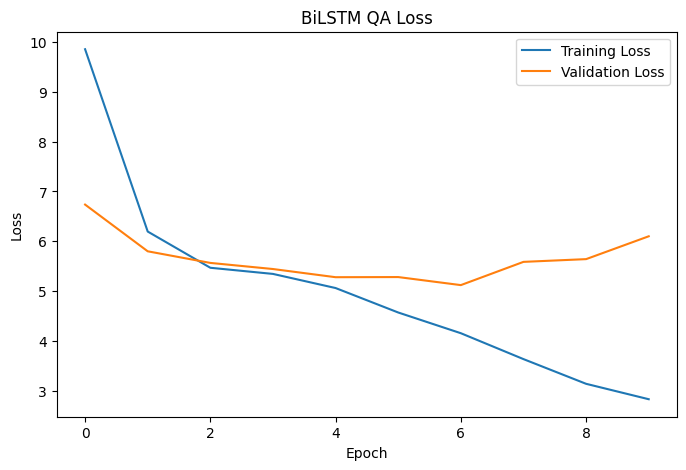

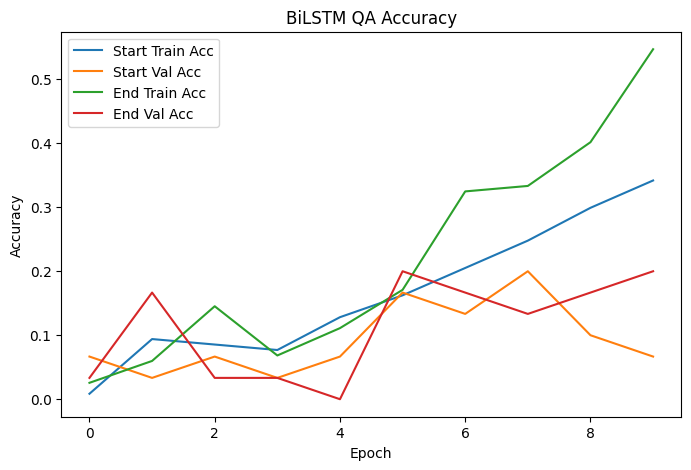

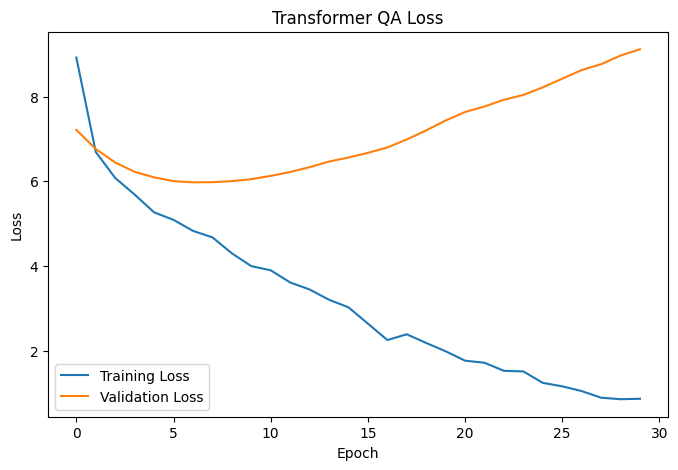

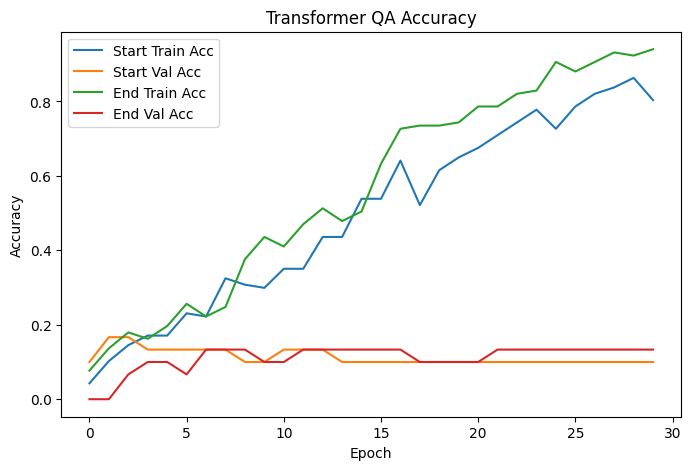

In [20]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["start_output_accuracy"], label="Start Train Acc")
    plt.plot(history.history["val_start_output_accuracy"], label="Start Val Acc")
    plt.plot(history.history["end_output_accuracy"], label="End Train Acc")
    plt.plot(history.history["val_end_output_accuracy"], label="End Val Acc")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_history(history_bilstm, "BiLSTM QA")
plot_history(history_transformer, "Transformer QA")

Evaluate both models

In [21]:
print("BiLSTM Evaluation:")
bilstm_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

print("Transformer Evaluation:")
transformer_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

BiLSTM Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - end_output_accuracy: 0.3947 - end_output_loss: 2.3963 - loss: 4.8874 - start_output_accuracy: 0.1842 - start_output_loss: 2.6440
Transformer Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - end_output_accuracy: 0.5526 - end_output_loss: 2.0899 - loss: 4.4050 - start_output_accuracy: 0.4737 - start_output_loss: 2.2610 


[4.405010223388672,
 2.26100492477417,
 2.089860677719116,
 0.5526315569877625,
 0.4736842215061188]

Inference function

In [22]:
def predict_answer(question, context, model, tokenizer, max_len=256):
    question_norm = normalize_arabic(question)
    context_norm = normalize_arabic(context)

    input_text = "[Q] " + question_norm + " [C] " + context_norm

    seq = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    start_probs, end_probs = model.predict(padded)

    context_offset = len(("[Q] " + question_norm + " [C]").split())

    # Prevent model from choosing tokens from [Q] or the question
    start_probs[0][:context_offset] = 0
    end_probs[0][:context_offset] = 0

    tokens = input_text.split()

    # Also prevent choosing padding / positions after real tokens
    start_probs[0][len(tokens):] = 0
    end_probs[0][len(tokens):] = 0

    start_idx = np.argmax(start_probs[0])
    end_idx = np.argmax(end_probs[0])

    if end_idx < start_idx:
        end_idx = start_idx

    predicted_tokens = tokens[start_idx:end_idx + 1]
    predicted_answer = " ".join(predicted_tokens)

    return predicted_answer, start_idx, end_idx

In [23]:
sample = df.iloc[0]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    bilstm_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Question: ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟
True Answer: تمثيلية إذاعية عن غزو فضائي
Predicted Answer: تمثيليه اذاعيه من
Start: 40
End: 42


In [24]:

sample = df.iloc[10]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    transformer_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
Question: ما الأسلوب السردي؟
True Answer: السرد غير الخطي
Predicted Answer: السرد غير الخطي
Start: 8
End: 10


Evaluating Transformer Model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━

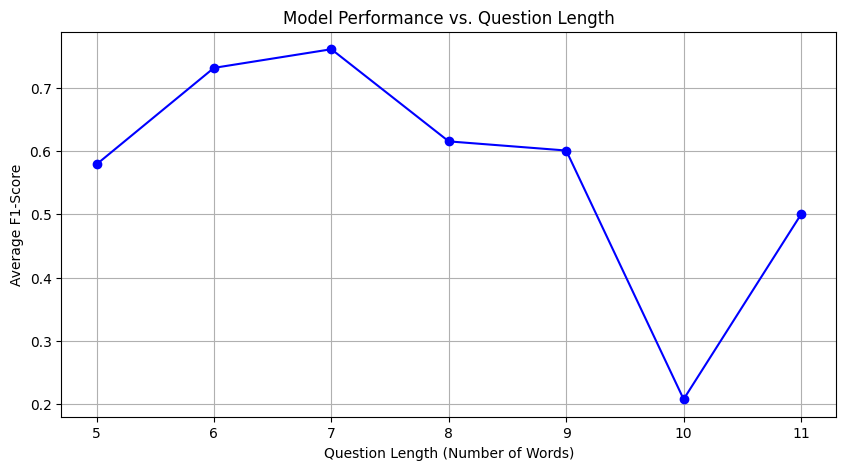

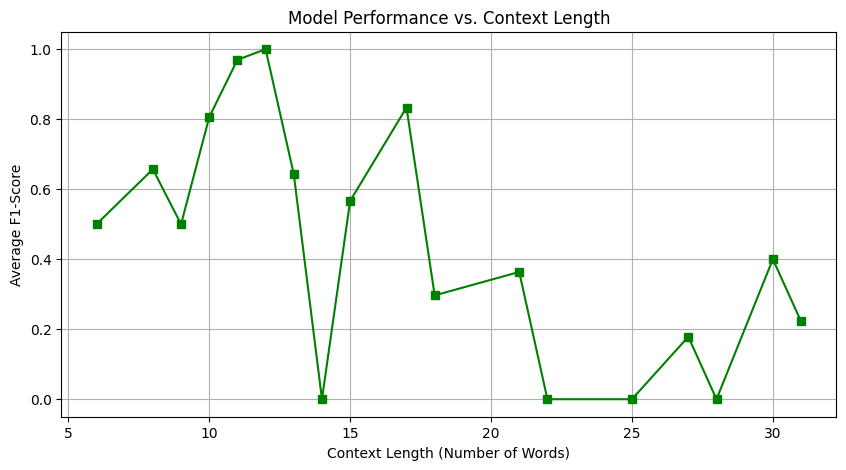

In [25]:
import collections
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define Standard QA Metrics
def compute_exact_match(true_answer, pred_answer):
    return int(true_answer == pred_answer)

def compute_f1(true_answer, pred_answer):
    gold_toks = true_answer.split()
    pred_toks = pred_answer.split()
    
    common = collections.Counter(gold_toks) & collections.Counter(pred_toks)
    num_same = sum(common.values())
    
    if len(gold_toks) == 0 or len(pred_toks) == 0:
        return int(gold_toks == pred_toks)
    if num_same == 0:
        return 0
        
    precision = 1.0 * num_same / len(pred_toks)
    recall = 1.0 * num_same / len(gold_toks)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

# 2. Run Evaluation and Track Question Lengths
results = []

print("Evaluating Transformer Model...")
for _, row in test_df.iterrows():
    question = row["question_norm"]
    context = row["context_norm"]
    true_answer = row["answer_norm"]
    
    # Get the prediction using your smart inference function
    pred_answer, _, _ = predict_answer(question, context, transformer_model, tokenizer, MAX_LEN)
    
    # Calculate metrics
    em = compute_exact_match(true_answer, pred_answer)
    f1 = compute_f1(true_answer, pred_answer)
    q_len = len(question.split()) # Length of the question
    c_len = len(context.split())  # Length of the context
    
    results.append({"q_len": q_len, "c_len": c_len, "em": em, "f1": f1})

results_df = pd.DataFrame(results)

# Print Overall Metrics
print(f"Overall Exact Match (EM): {results_df['em'].mean() * 100:.2f}%")
print(f"Overall F1-Score: {results_df['f1'].mean() * 100:.2f}%\n")

# 3. Behavioral Analysis Plot: Question Length vs Performance
# Group the results by question length and get the average F1 score for each length
q_len_analysis = results_df.groupby("q_len")["f1"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(q_len_analysis["q_len"], q_len_analysis["f1"], marker='o', linestyle='-', color='b')
plt.title("Model Performance vs. Question Length")
plt.xlabel("Question Length (Number of Words)")
plt.ylabel("Average F1-Score")
plt.grid(True)
plt.show()

# Optional: You can do the exact same plot for Context Length!
c_len_analysis = results_df.groupby("c_len")["f1"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(c_len_analysis["c_len"], c_len_analysis["f1"], marker='s', linestyle='-', color='g')
plt.title("Model Performance vs. Context Length")
plt.xlabel("Context Length (Number of Words)")
plt.ylabel("Average F1-Score")
plt.grid(True)
plt.show()